# Intro

1. Code to calculate Rainbow-KRAKEN protocol
2. Only Inputs needs to be modified

# Functions

In [1]:
import numpy as np
import math

from scipy import integrate
import scipy
from scipy import interpolate, special, integrate
from scipy.interpolate import interp1d
from scipy.integrate import quad

import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm

# from sympy import *
# from sympy import fourier_transform
# from sympy import fourier_transform

# Set the default font size to 22
plt.rcParams.update({'font.size': 22})

%matplotlib inline
%run KRAKEN_functions.ipynb

Loading functions


# Inputs (only part of the code that needs to be modified to change the system)

In [2]:
v_tau=0.0
hbar = 0.6582119569 


###############################################
# XUV pulse parameters
###############################################


v_omega_1=60.15/hbar #v_sigma_1=0.25/hbar   
# !!!!!! Remember v_omega_1 = v_omega_1-v_omega_g   !!!!!!
# so for spin orbit splitting we choose a different excitation frequency. all variables _p are for spin orbit splitting
v_omega_1_p=(60.15+0.177)/hbar #v_sigma_1_p=0.25/hbar

v_sigma_1=0.25/hbar
v_sigma_1_p=v_sigma_1 # pulse parameters for spin orbit splitting

v_A1 = 1.0
v_phi_1=0.0

###############################################
# Parameters for the IR pulses
###############################################

v_omega_2=1.5/hbar # not used 
v_omega_2_narrow = 1.5/hbar  # reference 
v_omega_2_broad = 1.5/hbar  # probe

v_sigma_2=0.15/hbar/2 # not used
v_sigma_2_narrow = 0.001/hbar
v_sigma_2_broad = 0.050/hbar # use for the sigma_xuv reduction
v_sigma_2_broad = 0.30/hbar # use for the normal simulations


v_A2 = 1.0
v_phi_2=0.0

###############################################
# Delay or fix the IR pulses
###############################################

time_probe = 1.0 # 0 if probe is fixed, 1.0 if probe is delayed w.r.t XUV
time_ref = 0.0 # 0 if reference is fixed, 1.0 if reference is delayed w.r.t XUV

###############################################
# Define the parameters for the system
###############################################

# Metastable state
v_Gamma_a = 0.037
v_omega_a = (60.15-1j*v_Gamma_a)/hbar
v_q_ag = -2.77
beta_a = -0.0003
v_Vaa=np.sqrt(v_Gamma_a/math.pi)/np.sqrt(hbar)
Vaa = v_Vaa

SPIN_ORBIT= 0 # put 1 for spin orbit splitting
VIA_DISCRETE = 1 # put 1 if there is a discrete level in the XUV continuum
SYMMETRIZE_TIME_TRACE = 0 # no longer used, ignore
NOISE = 0
std_dev = 0
SMALL_SIGMA_2 = 1

###############################################
# Define the detection parameters
###############################################

v_E=61.75/hbar # used only if you want to probe a certain energy. A grid is used by default
Ef_initial = 58. # in eV
Ef_final = 68. # in eV

N_Ef = 400 # Number of subdivisions for the detection energy
N_tau = 4601 # Number of time steps in the scan
time_limits = 400 # Time limits in fs (goes from -time_limits to +time_limits)

N_interpolation = 101 # number of bins in the interpolation along both directions, in energy


In [3]:

###############################################
# Prepare the input for the function
###############################################

params =   [v_A1,v_A2,v_sigma_1,  v_sigma_2, v_sigma_2_broad,v_sigma_2_narrow, v_phi_1,v_phi_2,v_omega_1,  v_omega_2, v_omega_2_broad, v_omega_2_narrow, v_E,v_omega_a,v_q_ag]
params_p = [v_A1,v_A2,v_sigma_1_p,v_sigma_2, v_sigma_2_broad,v_sigma_2_narrow, v_phi_1,v_phi_2,v_omega_1_p,v_omega_2, v_omega_2_broad, v_omega_2_narrow, v_E,v_omega_a,v_q_ag]    
params_system = [params, params_p]
params_protocol = VIA_DISCRETE, SPIN_ORBIT, time_probe, time_ref
params_simulation =[Ef_initial, Ef_final,N_Ef, N_tau, time_limits,N_interpolation]

###############################################
# Setup the figures and axes for display
###############################################

# 1. Time traces
fig_time_traces, [ax_time_traces_1, ax_time_traces_2, ax_time_traces_3] = plt.subplots(nrows=3, ncols=1, figsize=(5,15));


plt.close(fig_time_traces)

# 2. Fourier transorm
fig_fourier_transform, [ax_fourier_transform_1,ax_fourier_transform_2,ax_fourier_transform_3] = plt.subplots(nrows=3, ncols=1, figsize=(5,15));

plt.close(fig_fourier_transform)

# 3. Rescaled Fourier transform
fig_fourier_rescaled, [[ax_fourier_rescaled_1,ax_fourier_rescaled_2],
                       [ax_fourier_rescaled_3,ax_fourier_rescaled_4],
                       [ax_fourier_rescaled_5,ax_fourier_rescaled_6]
                      ]= plt.subplots(nrows=3, ncols=2, figsize=(10,15));

plt.close(fig_fourier_rescaled)


# 4. Interpolated rescaled Fourier transform
fig_interpolated, [[ax_interpolated_1,ax_interpolated_2,ax_interpolated_3],
                   [ax_interpolated_4,ax_interpolated_5,ax_interpolated_6],
                   [ax_interpolated_7,ax_interpolated_8,ax_interpolated_9]]= plt.subplots(nrows=3, ncols=3, figsize=(15,15));

plt.close(fig_interpolated)


axes_ = [ax_time_traces_1, ax_time_traces_2, ax_time_traces_3,
        ax_fourier_transform_1,ax_fourier_transform_2,ax_fourier_transform_3,
        ax_fourier_rescaled_1,ax_fourier_rescaled_2,
        ax_fourier_rescaled_3,ax_fourier_rescaled_4,
        ax_fourier_rescaled_5,ax_fourier_rescaled_6,
        ax_interpolated_1,ax_interpolated_2,ax_interpolated_3,
        ax_interpolated_4,ax_interpolated_5,ax_interpolated_6,
        ax_interpolated_7,ax_interpolated_8,ax_interpolated_9];



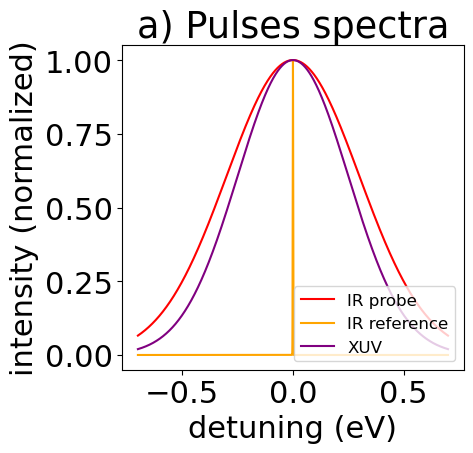

In [4]:
delta_range = 0.7
grid_omega_g = np.linspace(-delta_range, delta_range,10000)
y1 = np.exp(-((grid_omega_g)**2)/(2*(hbar*v_sigma_2_broad)**2))
y2 = np.exp(-((grid_omega_g)**2)/(2*(hbar*v_sigma_2_narrow)**2))
y3 = np.exp(-((grid_omega_g)**2)/(2*(hbar*v_sigma_1)**2))

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,5))
ax.plot(grid_omega_g,y1,'r',label='IR probe')
ax.plot(grid_omega_g,y2,'orange',label='IR reference')
ax.set_xlabel('detuning (eV)',fontsize=22)
ax.set_ylabel('intensity (normalized)',fontsize=22)
ax.plot(grid_omega_g,y3,'purple',label='XUV')

ax.set_title('a) Pulses spectra')

ax.legend(fontsize=12,loc='lower right')

fig.tight_layout()

fig.savefig('pulses.pdf')

In [5]:
# DO NOT USE, LEAVE AS IS
NOISE=0
std_dev = 0.2

# Run the simulations

In [6]:
return_from_RK = rainbow_kraken_no_plots(params_system,params_protocol,params_simulation,axes_)

/tmp/ipykernel_12639/3329103486.py:8: RuntimeWarning: overflow encountered in multiply
  VIA_DISCRETE*(beta_a-1./epsilon_Ea)*(q_ag-1j)*
/tmp/ipykernel_12639/3329103486.py:8: RuntimeWarning: invalid value encountered in multiply
  VIA_DISCRETE*(beta_a-1./epsilon_Ea)*(q_ag-1j)*
/tmp/ipykernel_12639/3329103486.py:7: RuntimeWarning: invalid value encountered in add
  temp = Form(*t_args)*(special.wofz(z21(*t_args))+
/tmp/ipykernel_12639/3329103486.py:7: RuntimeWarning: invalid value encountered in multiply
  temp = Form(*t_args)*(special.wofz(z21(*t_args))+


Fano


In [7]:
# Unpack the variables for individual analysis or plotting

[grid_Ef, freq, X_Ef, Y_tau, Y_freq, Z_RK_total, Z_RK_FT, Z_RK_FT_rs_analytical, Z_RK_FT_rs_intuitive,
           Z_RK_FT_rs_analytical_mod, Z_RK_FT_rs_intuitive_mod, spectrum_correction_analytical, 
           spectrum_correction_intuitive, mod,
           X_shift,Y_rescaled, X_interpolate, Y_interpolate, Z_inter_RK_FT, Z_inter_RK_FT_rs_analytical,
           Z_inter_RK_FT_rs_analytical_mod, Z_inter_RK_FT_rs_intuitive, Z_inter_RK_FT_rs_intuitive_mod,
           rho_predicted,fid,fid_sigma_2_corrected,purity,purity_sigma_2_corrected] = return_from_RK

## Interferogram

/usr/lib/python3/dist-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


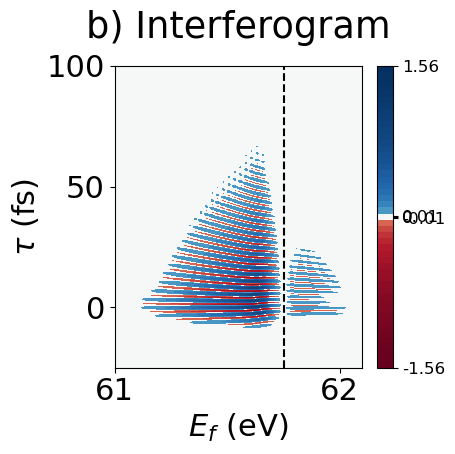

In [9]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

# Assume X_Ef, Y_tau, Z_RK_total, v_omega_a, v_omega_2_narrow, and hbar are defined here
maxx = 1.3
vv = np.linspace(-1.2 * maxx, 1.2 * maxx, 50)
linthresh = 0.01
norm3 = SymLogNorm(linthresh=linthresh, linscale=1.0, vmin=-1.2*maxx, vmax=1.2*maxx)

# Plot
contour1 = ax1.contourf(X_Ef, Y_tau, np.transpose(Z_RK_total), vv, cmap='RdBu', norm=norm3)
ax1.set_ylim(-25, 100)
ax1.set_xlim(61, 62.1)
ax1.set_ylabel(r'$\tau$ (fs)')
ax1.set_xlabel(r'$E_f$ (eV)')
ax1.set_title('b) Interferogram', pad=20)  # Adjusted title position


# Create colorbar and set font size for its labels
cbar = fig.colorbar(contour1, ax=ax1, orientation='vertical')

ticks = [-1.2*maxx, -linthresh, 0, linthresh, 1.2*maxx]
cbar.set_ticks(ticks)
tick_labels = [str(tick) for tick in ticks]  # Convert tick values to string if needed
cbar.set_ticklabels(tick_labels)

cbar.ax.yaxis.label.set_size(12) # For vertical colorbar, adjust y-axis label
cbar.ax.tick_params(labelsize=12) # Set font size for tick labels

# Plot references
wd = (hbar*np.real(v_omega_a)+hbar*v_omega_2_broad-v_q_ag*np.abs(np.imag(hbar*v_omega_a)))
xeff = (X_Ef[0,:])
wd2 = xeff - hbar*np.real(v_omega_a) + v_q_ag*np.abs(np.imag(hbar*v_omega_a))
ax1.axvline(x=wd, color='k', linestyle='--')

# Save files
fig.tight_layout()
fig.savefig('interferogram.pdf')


## Fourier transform

In [10]:
DEBUG=0
if DEBUG==1:
    
    # Set up grids
    time_range = 2.*time_limits
    grid_Ef = np.linspace(Ef_initial,Ef_final,N_Ef) # Energy grid in angular frequency
    grid_Omegaf = grid_Ef/hbar
    grid_tau = np.linspace(-time_limits,time_limits,N_tau)
    X_Ef,Y_tau = np.meshgrid(grid_Ef,grid_tau)
    X_Omegaf,Y_tau = np.meshgrid(grid_Omegaf,grid_tau)
    s_time_interval=(time_range)/N_tau # define the time interval
    f_range = 1./(2.*s_time_interval)  # frequency range based on the interval
    freq = 2.*math.pi*np.linspace(-f_range,f_range,N_tau)*0.658  # define the frequency array
    X_Ef,Y_freq = np.meshgrid(grid_Ef,freq)
    

    # Define the array to hold the spectra to get the spectra
    Z_RK_FT = Z_RK_total*np.transpose(np.exp(-Y_tau**2/(2*60**2))).copy() # Copy the array where the FT will be
    Z_RK_FT[np.isnan(Z_RK_FT)] = 0 # replace nans with zeros

    # Calculate the Fourier transform
    
    for aa in range(len(grid_Ef)):
        Z_RK_FT[aa,:] = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(Z_RK_FT[aa,:]))) 
    Z_RK_FT = np.transpose(Z_RK_FT)
    Z_RK_FT[np.isnan(Z_RK_FT)] = 0


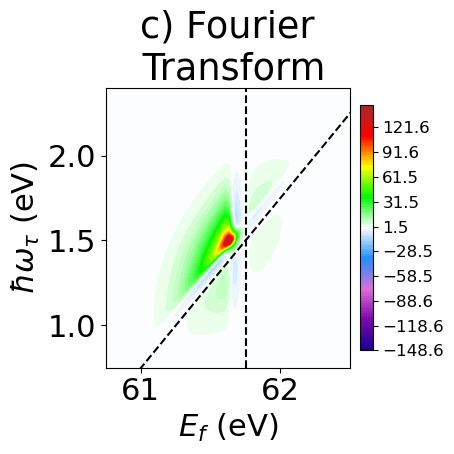

In [11]:
figure_procedure_Z_RK_FT = Z_RK_FT.copy()

y_for_plotting = np.real(figure_procedure_Z_RK_FT)

#figure_procedure_Z_RK_FT_rescaled = Z_RK_FT.copy() / gaussian_for_correction_2 * gaussian_should_be

# Assuming you have already defined X_Ef, Y_freq, Z_RK_FT somewhere in your code

plt.rcParams.update({'font.size': 22})

# Create a custom colormap with white at zero, blue for negative, and red for positive values
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', ['blue', 'white', 'red'])

# Create a figure and a single subplot
fig, ax_fourier_transform_1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

# Plotting the real part of Z_RK_FT
#maxx1 = np.amax(np.abs(figure_procedure_Z_RK_FT))
#vv1 = np.linspace(-1.2*maxx1, 1.2*maxx1, 50)

# Using the custom colormap

max_abs_value = np.amax(np.abs(y_for_plotting))

#max_abs_value = 300.0

v = np.linspace(-max_abs_value,max_abs_value,100)
cont1 = ax_fourier_transform_1.contourf(X_Ef, Y_freq, y_for_plotting, v, cmap='lund')

# Create colorbar and set font size for its labels
cbar = plt.colorbar(cont1, ax=ax_fourier_transform_1, fraction=0.046, pad=0.04)
cbar.ax.yaxis.label.set_size(12) # For vertical colorbar, adjust y-axis label
cbar.ax.tick_params(labelsize=12) # Set font size for tick labels


#ax_fourier_transform_1.set_aspect('equal', adjustable='box')

wd = (hbar*np.real(v_omega_a)+hbar*v_omega_2_broad-v_q_ag*np.abs(np.imag(hbar*v_omega_a)))
xeff = (X_Ef[0,:])
wd2 = xeff - hbar*np.real(v_omega_a) + v_q_ag*np.abs(np.imag(hbar*v_omega_a))
ax_fourier_transform_1.axvline(x=wd, color='k', linestyle='--')
ax_fourier_transform_1.plot(xeff, wd2, color='k', linestyle='--')


# Optionally, set titles or labels if necessary
ax_fourier_transform_1.set_title("c) Fourier\n Transform")  # Title on two lines
ax_fourier_transform_1.set_xlim(60.75, 62.5)
ax_fourier_transform_1.set_ylim(0.75, 2.4)

ax_fourier_transform_1.set_ylabel(r'$\hbar \omega_{\tau}$ (eV)')
ax_fourier_transform_1.set_xlabel(r'$E_f$ (eV)')

# Display the plot
plt.tight_layout()
plt.savefig('Fourier_transform.pdf')


## Fourier transform rescaled

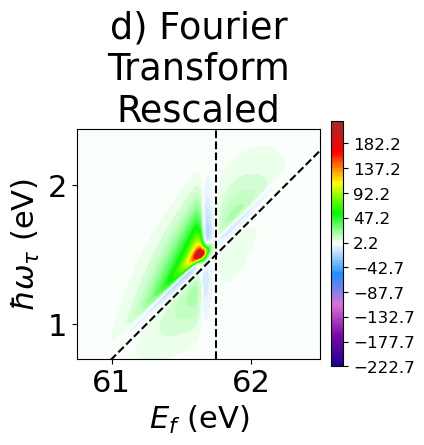

In [12]:
# Assuming you have already defined X_Ef, Y_freq, Z_RK_FT_rescaled somewhere in your code

# Create a custom colormap with white at zero, blue for negative, and red for positive values
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', ['blue', 'white', 'red'])

# Create a figure and a single subplot
fig, ax_fourier_transform_1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

# Plotting the real part of Z_RK_FT_rescaled
#maxx1 = np.amax(np.abs(figure_procedure_Z_RK_FT_rescaled))
#vv1 = np.linspace(-1.2*maxx1, 1.2*maxx1, 50)

# Z_RK_FT_rs_analytical_mod

y_for_plotting = np.real(Z_RK_FT_rs_analytical_mod)

# Using the custom colormap
max_abs_value = np.amax(np.abs(y_for_plotting ))
v = np.linspace(-max_abs_value,max_abs_value,100)
cont1 = ax_fourier_transform_1.contourf(X_Ef, Y_freq, y_for_plotting, v, cmap='lund')

# Create colorbar and set font size for its labels
cbar = plt.colorbar(cont1, ax=ax_fourier_transform_1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # Set font size for tick labels

ax_fourier_transform_1.set_aspect('equal', adjustable='box')

# Optionally, set titles or labels if necessary
ax_fourier_transform_1.set_title("d) Fourier\nTransform\nRescaled")  # Title on two lines
ax_fourier_transform_1.set_xlim(60.75, 62.5)
ax_fourier_transform_1.set_ylim(0.75, 2.4)

wd = (hbar*np.real(v_omega_a)+hbar*v_omega_2_broad-v_q_ag*np.abs(np.imag(hbar*v_omega_a)))
xeff = (X_Ef[0,:])
wd2 = xeff - hbar*np.real(v_omega_a) + v_q_ag*np.abs(np.imag(hbar*v_omega_a))
ax_fourier_transform_1.axvline(x=wd, color='k', linestyle='--')
ax_fourier_transform_1.plot(xeff, wd2, color='k', linestyle='--')

ax_fourier_transform_1.set_ylabel(r'$\hbar \omega_{\tau}$ (eV)')
ax_fourier_transform_1.set_xlabel(r'$E_f$ (eV)')

# Display the plot
plt.tight_layout()
plt.savefig('Fourier_transform_rescaled.pdf')


## Density matrix

In [13]:
y_pred_norm = rho_predicted/np.trace(rho_predicted)

symmetrized = 1/2*(Z_inter_RK_FT_rs_analytical_mod+np.conjugate(np.transpose(Z_inter_RK_FT_rs_analytical_mod)))
symmetrized = symmetrized/np.trace(symmetrized)

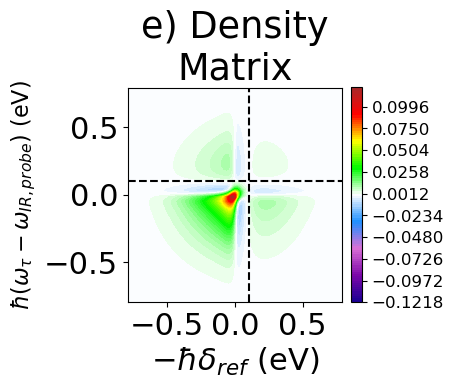

In [14]:

# Assuming you have already defined X_Ef, Y_freq, Z_RK_FT_rescaled somewhere in your code

# Create a custom colormap with white at zero, blue for negative, and red for positive values
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', ['blue', 'white', 'red'])

# Create a figure and a single subplot
fig, ax_fourier_transform_1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))


y_for_plotting = np.real(Z_inter_RK_FT_rs_analytical_mod/np.trace(Z_inter_RK_FT_rs_analytical_mod))

# Using the custom colormap
max_abs_value = np.amax(np.abs( y_for_plotting  ))
v = np.linspace(-max_abs_value,max_abs_value,100)
cont1 = ax_fourier_transform_1.contourf(X_interpolate, Y_interpolate, y_for_plotting , v, cmap='lund')

# Create colorbar and set font size for its labels
cbar = plt.colorbar(cont1, ax=ax_fourier_transform_1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # Set font size for tick labels

wd = (-v_q_ag*np.abs(np.imag(hbar*v_omega_a)))
xeff = (X_Ef[0,:])
wd2 = xeff - hbar*np.real(v_omega_a) + v_q_ag*np.abs(np.imag(hbar*v_omega_a))
ax_fourier_transform_1.axvline(x=wd, color='k', linestyle='--')
ax_fourier_transform_1.axhline(y=wd, color='k', linestyle='--')



# Optionally, set titles or labels if necessary
ax_fourier_transform_1.set_title("e) Density\nMatrix")  # Title on two lines
ax_fourier_transform_1.set_ylabel(r'$\hbar (\omega_{\tau}-\omega_{IR,probe})$ (eV)',fontsize=16)
ax_fourier_transform_1.set_xlabel(r'$-\hbar \delta_{ref}$ (eV)')

ax_fourier_transform_1.set_aspect('equal', adjustable='box')


# Display the plot
plt.tight_layout()
plt.savefig('Density_matrix.pdf')


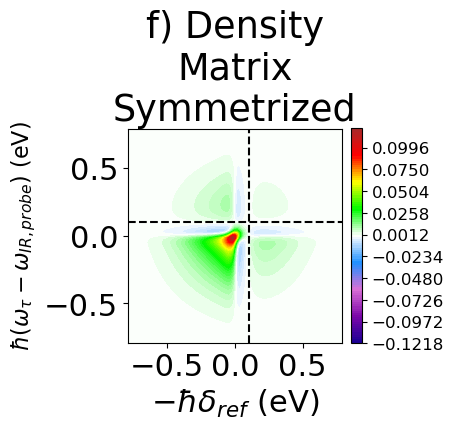

In [15]:

# Assuming you have already defined X_Ef, Y_freq, Z_RK_FT_rescaled somewhere in your code

# Create a custom colormap with white at zero, blue for negative, and red for positive values
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', ['blue', 'white', 'red'])

# Create a figure and a single subplot
fig, ax_fourier_transform_1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

# Plotting the real part of Z_RK_FT_rescaled
maxx1 = np.amax(np.abs(np.real(symmetrized)))
vv1 = np.linspace(-1.2*maxx1, 1.2*maxx1, 50)

y_for_plotting = np.real(symmetrized)

# Using the custom colormap
max_abs_value = np.amax(np.abs( y_for_plotting  ))
v = np.linspace(-max_abs_value,max_abs_value,100)
cont1 = ax_fourier_transform_1.contourf(X_interpolate, Y_interpolate, y_for_plotting , v, cmap='lund')

# Create colorbar and set font size for its labels
cbar = plt.colorbar(cont1, ax=ax_fourier_transform_1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # Set font size for tick labels

# cbar2 = fig.colorbar(cp2, ax=ax2, fraction=0.046, pad=0.04)  # Adjust the colorbar height


wd = (-v_q_ag*np.abs(np.imag(hbar*v_omega_a)))
xeff = (X_Ef[0,:])
wd2 = xeff - hbar*np.real(v_omega_a) + v_q_ag*np.abs(np.imag(hbar*v_omega_a))
ax_fourier_transform_1.axvline(x=wd, color='k', linestyle='--')
ax_fourier_transform_1.axhline(y=wd, color='k', linestyle='--')



# Optionally, set titles or labels if necessary
ax_fourier_transform_1.set_title("f) Density\nMatrix\nSymmetrized")  # Title on two lines
ax_fourier_transform_1.set_ylabel(r'$\hbar (\omega_{\tau}-\omega_{IR,probe})$ (eV)',fontsize=16)
ax_fourier_transform_1.set_xlabel(r'$-\hbar \delta_{ref}$ (eV)')

ax_fourier_transform_1.set_aspect('equal', adjustable='box')


# Display the plot
plt.tight_layout()
plt.savefig('Density_matrix_symmetrized.pdf')


In [16]:
fid_sigma_2_corrected, purity_sigma_2_corrected

((1.0003227018231008432-0.00028732735422655167705j),
 (0.9970558713602574-0.0009911845768938586j))

# Reconstructed / predicted density matrix

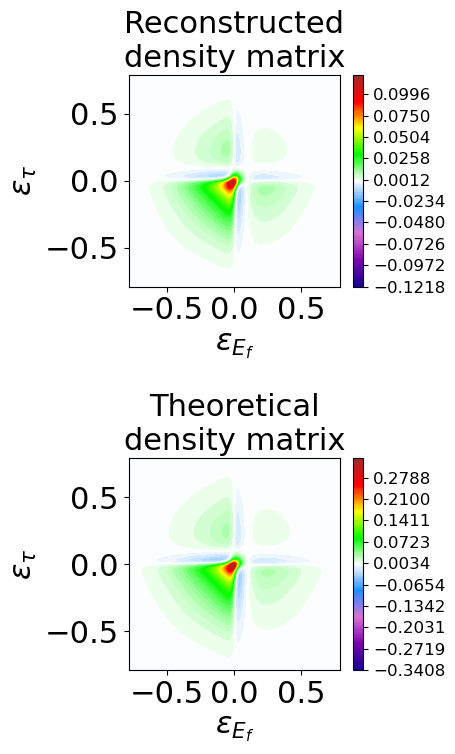

In [17]:
import numpy as np
import matplotlib.pyplot as plt


symmetrized = 1/2*(Z_inter_RK_FT_rs_analytical_mod+np.conjugate(np.transpose(Z_inter_RK_FT_rs_analytical_mod)))
symmetrized = Z_inter_RK_FT_rs_analytical_mod
#symmetrized = Z_inter_RK_FT
symmetrized = symmetrized/np.trace(symmetrized)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8))


y_for_plotting_1 = np.real(symmetrized)

max_abs_value = np.amax(np.abs( y_for_plotting_1 ))

gam = np.abs(np.imag(hbar*v_omega_a))

# First contour plot
max_abs_value = np.amax(np.abs(np.real(symmetrized)))
v = np.linspace(-max_abs_value,max_abs_value,100)
cp1 = ax1.contourf(X_interpolate, Y_interpolate, y_for_plotting_1, v,cmap='lund')

cbar1 = fig.colorbar(cp1, ax=ax1, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('Reconstructed\ndensity matrix',fontsize=22)
ax1.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax1.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax1.set_aspect('equal', adjustable='box')
ax1.tick_params(labelsize=22)


# Second contour plot

y_for_plotting_2 = np.real(rho_predicted)

max_abs_value = np.amax(np.abs(y_for_plotting_2))

v = np.linspace(-max_abs_value,max_abs_value,100)

cp2 = ax2.contourf(X_interpolate, Y_interpolate, y_for_plotting_2, v, cmap='lund')

cbar2 = fig.colorbar(cp2, ax=ax2, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar2.ax.tick_params(labelsize=12)


ax2.set_title('Theoretical\ndensity matrix',fontsize=22)
ax2.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax2.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax2.set_aspect('equal', adjustable='box')
ax2.tick_params(labelsize=22)


fig.tight_layout()

#fig.savefig('density_matrix_Helium_new.pdf')
#fig.savefig('density_matrix_Helium_new.png')

#fig.savefig('density_matrix_Argon_new.pdf')
#fig.savefig('density_matrix_Argon_new.png')



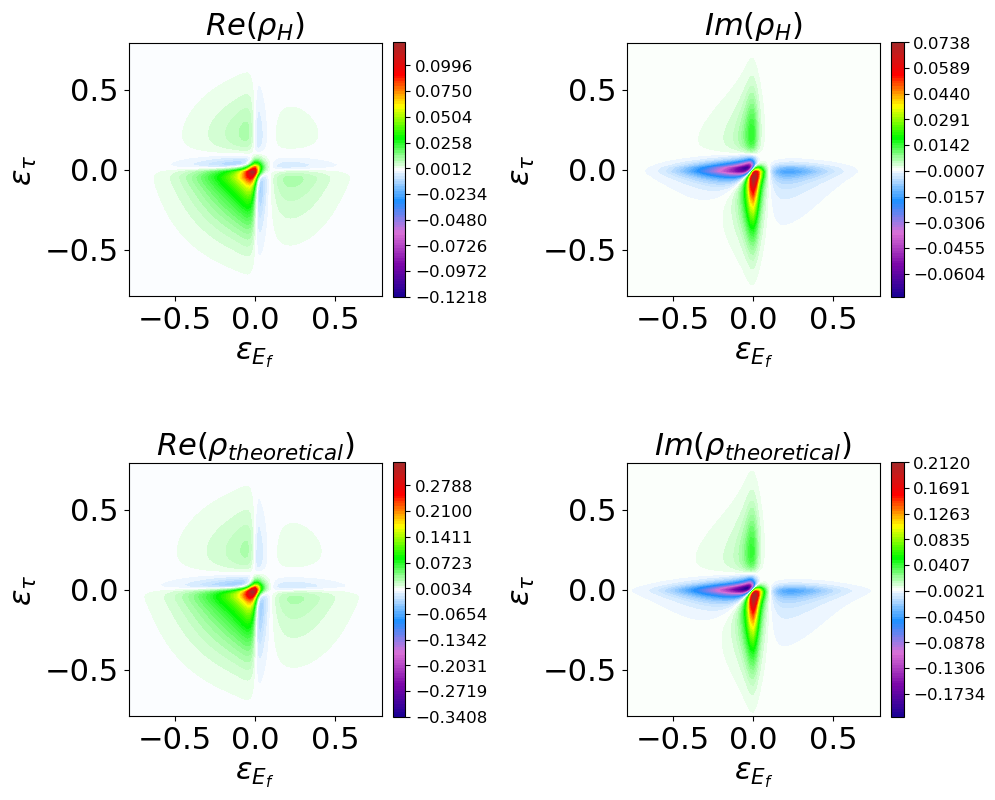

In [18]:
import numpy as np
import matplotlib.pyplot as plt


symmetrized = 1/2*(Z_inter_RK_FT_rs_analytical_mod+np.conjugate(np.transpose(Z_inter_RK_FT_rs_analytical_mod)))
symmetrized = Z_inter_RK_FT_rs_analytical_mod
#symmetrized = Z_inter_RK_FT
symmetrized = symmetrized/np.trace(symmetrized)

# Plotting
fig, [[ax1, ax1b] , [ax2, ax2b]] = plt.subplots(2, 2, figsize=(10, 10))


y_for_plotting_1 = np.real(symmetrized)
max_abs_value = np.amax(np.abs( y_for_plotting_1 ))
gam = np.abs(np.imag(hbar*v_omega_a))

# First contour plot
v = np.linspace(-max_abs_value,max_abs_value,100)
cp1 = ax1.contourf(X_interpolate, Y_interpolate, y_for_plotting_1, v,cmap='lund')

cbar1 = fig.colorbar(cp1, ax=ax1, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar1.ax.tick_params(labelsize=12)

ax1.set_title(r'$Re(\rho_H)$',fontsize=22)
ax1.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax1.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax1.set_aspect('equal', adjustable='box')
ax1.tick_params(labelsize=22)

############################################################################################

y_for_plotting_1b = np.imag(symmetrized)
max_abs_value = np.amax(np.abs( y_for_plotting_1b ))
gam = np.abs(np.imag(hbar*v_omega_a))

# First contour plot
v = np.linspace(-max_abs_value,max_abs_value,100)
cp1b = ax1b.contourf(X_interpolate, Y_interpolate, y_for_plotting_1b, v,cmap='lund')

cbar1b = fig.colorbar(cp1b, ax=ax1b, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar1b.ax.tick_params(labelsize=12)

ax1b.set_title(r'$Im(\rho_H)$',fontsize=22)
ax1b.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax1b.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax1b.set_aspect('equal', adjustable='box')
ax1b.tick_params(labelsize=22)



############################################################################################

# Second contour plot

y_for_plotting_2 = np.real(rho_predicted)
max_abs_value = np.amax(np.abs(y_for_plotting_2))
v = np.linspace(-max_abs_value,max_abs_value,100)

cp2 = ax2.contourf(X_interpolate, Y_interpolate, y_for_plotting_2, v, cmap='lund')

cbar2 = fig.colorbar(cp2, ax=ax2, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar2.ax.tick_params(labelsize=12)


ax2.set_title(r'$Re(\rho_{theoretical})$',fontsize=22)
ax2.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax2.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax2.set_aspect('equal', adjustable='box')
ax2.tick_params(labelsize=22)

############################################################################################


y_for_plotting_2b = np.imag(rho_predicted)
max_abs_value = np.amax(np.abs(y_for_plotting_2b))
v = np.linspace(-max_abs_value,max_abs_value,100)

cp2b = ax2b.contourf(X_interpolate, Y_interpolate, y_for_plotting_2b, v, cmap='lund')

cbar2b = fig.colorbar(cp2b, ax=ax2b, fraction=0.046, pad=0.04)  # Adjust the colorbar height
cbar2b.ax.tick_params(labelsize=12)


ax2b.set_title(r'$Im(\rho_{theoretical})$',fontsize=22)
ax2b.set_xlabel(r'$\epsilon_{E_f}$',fontsize=22)
ax2b.set_ylabel(r'$\epsilon_\tau$',fontsize=22)
ax2b.set_aspect('equal', adjustable='box')
ax2b.tick_params(labelsize=22)

############################################################################################


fig.subplots_adjust(hspace=0.2)
fig.subplots_adjust(wspace=0.8)


#fig.tight_layout()

fig.savefig('density_matrix_Helium_new.pdf')
#fig.savefig('density_matrix_Helium_new.png')

#fig.savefig('density_matrix_Argon_new.pdf')
#fig.savefig('density_matrix_Argon_new.png')



# Analysis of the envelopes

In [19]:
def envelope_function(X_Ef,Y_freq,v_omega_1,v_omega_2_broad,v_sigma_1,v_sigma_2_broad):
    
    # sigmas are in frequencies
    v_sigma = np.sqrt( v_sigma_1**2 + v_sigma_2_broad**2 )
    v_sigma_t = np.sqrt( 1./v_sigma_1**2 + 1./v_sigma_2_broad**2 )

    spectrum_correction_analytical = ( np.exp(-(Y_freq-v_omega_2_broad*hbar 
                      + v_sigma_2_broad**2/v_sigma**2 *(hbar*v_omega_1 + hbar*v_omega_2_broad - X_Ef) )**2 
                                       *v_sigma_t**2/(2*hbar**2) ) 
            * np.exp(-(hbar*v_omega_1 + hbar*v_omega_2_broad - X_Ef)**2/(2*hbar**2*v_sigma**2)) +0.01 )
    
    return spectrum_correction_analytical

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12639/1621530444.py:12: SyntaxWarning: invalid escape sequence '\s'
  name_ = ['$\sigma_{IR,probe}$ =$0.01 \sigma_{XUV}$',
/tmp/ipykernel_12639/1621530444.py:13: SyntaxWarning: invalid escape sequence '\s'
  '$\sigma_{IR,probe}$ =$0.3 \sigma_{XUV}$',
/tmp/ipykernel_12639/1621530444.py:14: SyntaxWarning: invalid escape sequence '\s'
  '$\sigma_{IR,probe}$ =$\sigma_{XUV}$',
/tmp/ipykernel_12639/1621530444.py:15: SyntaxWarning: invalid escape sequence '\s'
  '$\sigma_{IR,probe}$ =$ 10 \sigma_{XUV}$']


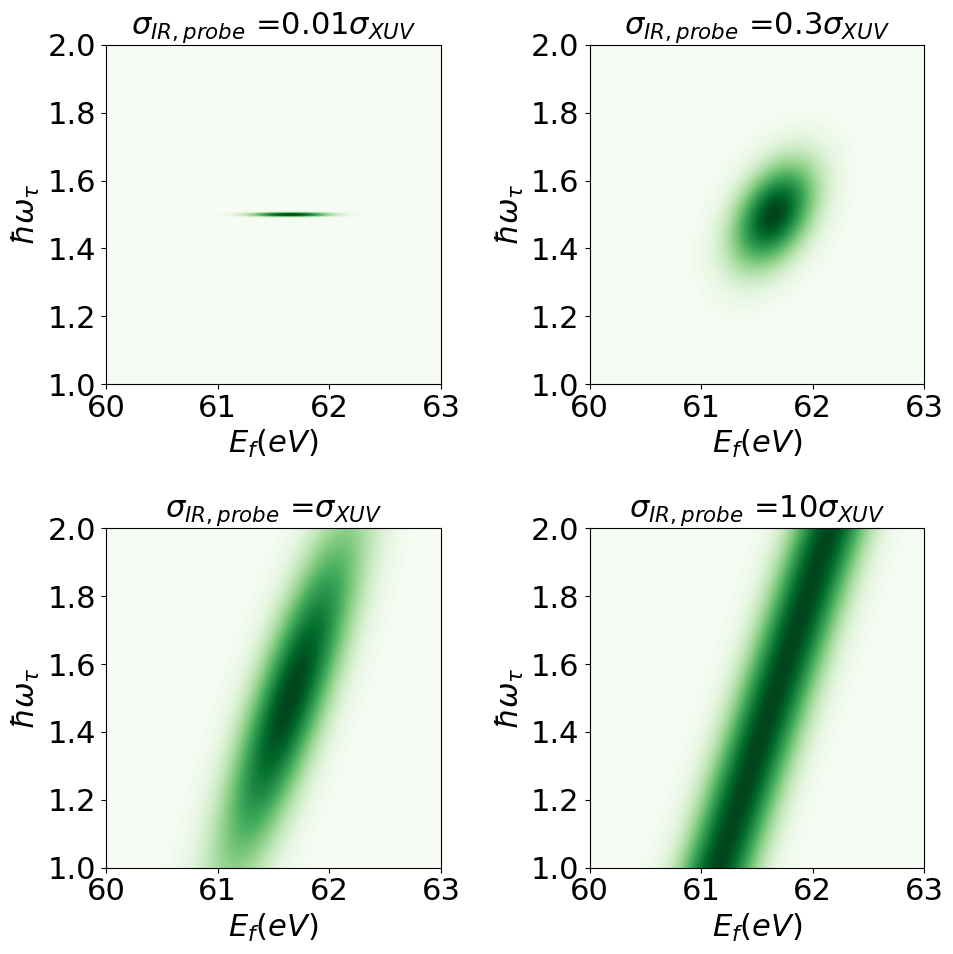

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing code
fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
x_p = np.linspace(60, 63, 1000)
y_p = np.linspace(1, 2, 1000)
X_p, Y_p = np.meshgrid(x_p, y_p)
ax_ = [ax1, ax2, ax3, ax4]
grid_sigma_2_ = [element * v_sigma_1 / hbar for element in [0.01, 0.3, 1.0, 10.0]]

name_ = ['$\sigma_{IR,probe}$ =$0.01 \sigma_{XUV}$',
         '$\sigma_{IR,probe}$ =$0.3 \sigma_{XUV}$',
         '$\sigma_{IR,probe}$ =$\sigma_{XUV}$',
         '$\sigma_{IR,probe}$ =$ 10 \sigma_{XUV}$']    


# Assuming envelope_function is defined elsewhere
for aaa in range(4):
    z = envelope_function(X_p, Y_p, v_omega_1, v_omega_2_broad, v_sigma_1, grid_sigma_2_[aaa])
    ax_[aaa].contourf(X_p, Y_p, z, 100, cmap='Greens')
    ax_[aaa].set_title(name_[aaa],fontsize=22)
    

# New code for labeling axes
for ax in ax_:
    ax.set_xlabel(r'$E_f (eV)$', fontsize=22)
    ax.set_ylabel(r'$\hbar \omega_\tau$', fontsize=22)

    
fig.tight_layout()
fig.savefig('envelopes.png')


# Argon

In [21]:
v_tau=0.0
hbar = 0.6582119569 


###############################################
# XUV pulse parameters
###############################################


v_omega_1=60.15/hbar #v_sigma_1=0.25/hbar   
# !!!!!! Remember v_omega_1 = v_omega_1-v_omega_g   !!!!!!
# so for spin orbit splitting we choose a different excitation frequency
v_omega_1_p=(60.15+0.177)/hbar #v_sigma_1_p=0.25/hbar

v_sigma_1=0.10/hbar
v_sigma_1_p=v_sigma_1 # pulse parameters for spin orbit splitting

v_A1 = 1.0
v_phi_1=0.0

###############################################
# Parameters for the IR pulses
###############################################

v_omega_2=1.5/hbar # not used 
v_omega_2_narrow = 1.5/hbar  # reference 
v_omega_2_broad = 1.5/hbar  # probe

v_sigma_2=0.15/hbar/2 # not used
v_sigma_2_narrow = 0.001/hbar
v_sigma_2_broad = 0.25/hbar

v_A2 = 1.0
v_phi_2=0.0

###############################################
# Delay or fix the IR pulses
###############################################

time_probe = 1.0 # 0 if probe is fixed, 1.0 if probe is delayed w.r.t XUV
time_ref = 0.0 # 0 if reference is fixed, 1.0 if reference is delayed w.r.t XUV

###############################################
# Define the parameters for the system
###############################################

# Metastable state
v_Gamma_a = 0.037
v_omega_a = (60.15-1j*v_Gamma_a)/hbar
v_q_ag = -2.77
beta_a = -0.0003
v_Vaa=np.sqrt(v_Gamma_a/math.pi)/np.sqrt(hbar)
Vaa = v_Vaa



SPIN_ORBIT= 1 # put 1 for spin orbit splitting
VIA_DISCRETE = 0 # put 1 if there is a discrete level in the XUV continuum
SYMMETRIZE_TIME_TRACE = 0 # no longer used, ignore

###############################################
# Define the detection parameters
###############################################

v_E=61.75/hbar # used only if you want to probe a certain energy. A grid is used by default
Ef_initial = 58. # in eV
Ef_final = 68. # in eV

N_Ef = 400 # Number of subdivisions for the detection energy
N_tau = 4601 # Number of time steps in the scan
time_limits = 400 # Time limits in fs (goes from -time_limits to +time_limits)

N_interpolation = 101 # number of bins in the interpolation along both directions, in energy


In [22]:

###############################################
# Prepare the input for the function
###############################################

params =   [v_A1,v_A2,v_sigma_1,  v_sigma_2, v_sigma_2_broad,v_sigma_2_narrow, v_phi_1,v_phi_2,v_omega_1,  v_omega_2, v_omega_2_broad, v_omega_2_narrow, v_E,v_omega_a,v_q_ag]
params_p = [v_A1,v_A2,v_sigma_1_p,v_sigma_2, v_sigma_2_broad,v_sigma_2_narrow, v_phi_1,v_phi_2,v_omega_1_p,v_omega_2, v_omega_2_broad, v_omega_2_narrow, v_E,v_omega_a,v_q_ag]    
params_system = [params, params_p]
params_protocol = VIA_DISCRETE, SPIN_ORBIT, time_probe, time_ref
params_simulation =[Ef_initial, Ef_final,N_Ef, N_tau, time_limits,N_interpolation]

###############################################
# Setup the figures and axes for display
###############################################

# 1. Time traces
fig_time_traces, [ax_time_traces_1, ax_time_traces_2, ax_time_traces_3] = plt.subplots(nrows=3, ncols=1, figsize=(5,15));


plt.close(fig_time_traces)

# 2. Fourier transorm
fig_fourier_transform, [ax_fourier_transform_1,ax_fourier_transform_2,ax_fourier_transform_3] = plt.subplots(nrows=3, ncols=1, figsize=(5,15));

plt.close(fig_fourier_transform)

# 3. Rescaled Fourier transform
fig_fourier_rescaled, [[ax_fourier_rescaled_1,ax_fourier_rescaled_2],
                       [ax_fourier_rescaled_3,ax_fourier_rescaled_4],
                       [ax_fourier_rescaled_5,ax_fourier_rescaled_6]
                      ]= plt.subplots(nrows=3, ncols=2, figsize=(10,15));

plt.close(fig_fourier_rescaled)


# 4. Interpolated rescaled Fourier transform
fig_interpolated, [[ax_interpolated_1,ax_interpolated_2,ax_interpolated_3],
                   [ax_interpolated_4,ax_interpolated_5,ax_interpolated_6],
                   [ax_interpolated_7,ax_interpolated_8,ax_interpolated_9]]= plt.subplots(nrows=3, ncols=3, figsize=(15,15));

plt.close(fig_interpolated)


axes_ = [ax_time_traces_1, ax_time_traces_2, ax_time_traces_3,
        ax_fourier_transform_1,ax_fourier_transform_2,ax_fourier_transform_3,
        ax_fourier_rescaled_1,ax_fourier_rescaled_2,
        ax_fourier_rescaled_3,ax_fourier_rescaled_4,
        ax_fourier_rescaled_5,ax_fourier_rescaled_6,
        ax_interpolated_1,ax_interpolated_2,ax_interpolated_3,
        ax_interpolated_4,ax_interpolated_5,ax_interpolated_6,
        ax_interpolated_7,ax_interpolated_8,ax_interpolated_9];



In [23]:
return_from_RK_argon = rainbow_kraken(params_system,params_protocol,params_simulation,axes_)

/tmp/ipykernel_12639/3329103486.py:8: RuntimeWarning: invalid value encountered in multiply
  VIA_DISCRETE*(beta_a-1./epsilon_Ea)*(q_ag-1j)*
/tmp/ipykernel_12639/3329103486.py:7: RuntimeWarning: invalid value encountered in multiply
  temp = Form(*t_args)*(special.wofz(z21(*t_args))+
/tmp/ipykernel_12639/899054185.py:81: RuntimeWarning: invalid value encountered in multiply
  Z_RK  = (Z_broadband*np.conjugate(Z_reference) + np.conjugate(Z_broadband)*(Z_reference)
/tmp/ipykernel_12639/899054185.py:83: RuntimeWarning: invalid value encountered in multiply
  Z_RK_p  = (Z_broadband_p*np.conjugate(Z_reference_p) + np.conjugate(Z_broadband_p)*(Z_reference_p)
/tmp/ipykernel_12639/899054185.py:87: RuntimeWarning: invalid value encountered in multiply
  Z_RK  = (Z_broadband*np.conjugate(Z_reference) + np.conjugate(Z_broadband)*(Z_reference) )
/tmp/ipykernel_12639/899054185.py:88: RuntimeWarning: invalid value encountered in multiply
  Z_RK_p  = (Z_broadband_p*np.conjugate(Z_reference_p) + np.co

Flat with spin orbit splitting


In [24]:
# Unpack the variables for individual analysis or plotting

[grid_Ef, freq, X_Ef, Y_tau, Y_freq, Z_RK_total, Z_RK_FT, Z_RK_FT_rs_analytical, Z_RK_FT_rs_intuitive,
           Z_RK_FT_rs_analytical_mod, Z_RK_FT_rs_intuitive_mod, spectrum_correction_analytical, 
           spectrum_correction_intuitive, mod,
           X_shift,Y_rescaled, X_interpolate, Y_interpolate, Z_inter_RK_FT, Z_inter_RK_FT_rs_analytical,
           Z_inter_RK_FT_rs_analytical_mod, Z_inter_RK_FT_rs_intuitive, Z_inter_RK_FT_rs_intuitive_mod,
           rho_predicted,fid,fid_sigma_2_corrected,purity,purity_sigma_2_corrected] = return_from_RK_argon

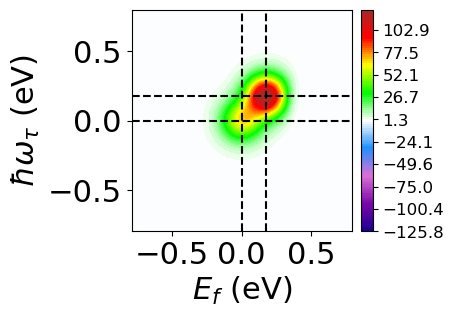

In [25]:

# Assuming you have already defined X_Ef, Y_freq, Z_RK_FT_rescaled somewhere in your code

# Create a custom colormap with white at zero, blue for negative, and red for positive values
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', ['blue', 'white', 'red'])

# Create a figure and a single subplot
fig, ax_fourier_transform_1 = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))


y_for_plotting = np.real(Z_inter_RK_FT_rs_analytical_mod)

# Using the custom colormap
max_abs_value = np.amax(np.abs( y_for_plotting  ))
v = np.linspace(-max_abs_value,max_abs_value,100)
cont1 = ax_fourier_transform_1.contourf(X_interpolate, Y_interpolate, y_for_plotting , v, cmap='lund')

# Create colorbar and set font size for its labels
cbar = plt.colorbar(cont1, ax=ax_fourier_transform_1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # Set font size for tick labels

# cbar2 = fig.colorbar(cp2, ax=ax2, fraction=0.046, pad=0.04)  # Adjust the colorbar height


wd = 0
xeff = (X_Ef[0,:])
wd2 = -hbar*(v_omega_1-v_omega_1_p)

ax_fourier_transform_1.axvline(x=wd, color='k', linestyle='--')
ax_fourier_transform_1.axhline(y=wd, color='k', linestyle='--')

ax_fourier_transform_1.axvline(x=wd2, color='k', linestyle='--')
ax_fourier_transform_1.axhline(y=wd2, color='k', linestyle='--')



# Optionally, set titles or labels if necessary
#ax_fourier_transform_1.set_title("f) Density\nMatrix\nSymmetrized")  # Title on two lines
ax_fourier_transform_1.set_ylabel(r'$\hbar \omega_{\tau}$ (eV)')
ax_fourier_transform_1.set_xlabel(r'$E_f$ (eV)')

ax_fourier_transform_1.set_aspect('equal', adjustable='box')


# Display the plot
plt.tight_layout()
plt.savefig('Density_matrix_symmetrized_argon.pdf')
